In [1]:
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/CPI_Research'

import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU') or "❌ SWITCH TO T4 GPU FIRST")

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install hmmlearn PyWavelets -q

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, random, warnings
warnings.filterwarnings('ignore')
from tensorflow import keras
from tensorflow.keras import layers
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from hmmlearn.hmm import GaussianHMM
import pywt

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

df = pd.read_csv(f'{FOLDER}/bangladesh_MASTER_dataset.csv', index_col=0, parse_dates=True)
orders = json.load(open(f'{FOLDER}/session1_orders.json'))
ARIMA_ORDER  = tuple(orders['ARIMA_ORDER'])
SARIMA_ORDER, SARIMA_SORDER = tuple(orders['SARIMA_ORDER']), tuple(orders['SARIMA_SORDER'])
print(f"Loaded orders → ARIMA{ARIMA_ORDER}, SARIMA{SARIMA_ORDER}x{SARIMA_SORDER}")

TRAIN_END, TEST_START, TEST_END = '2020-12-01', '2021-01-01', '2026-04-01'
y_full  = df['CPI'].loc['2000-01-01':TEST_END]
y_train = y_full.loc[:TRAIN_END];  y_test = y_full.loc[TEST_START:]

RESULTS_PATH = f'{FOLDER}/all_model_results.csv'
results_log = pd.read_csv(RESULTS_PATH).to_dict('records')

def log_result(name, actual, pred):
    a, p = np.asarray(actual,float).ravel(), np.asarray(pred,float).ravel()
    row = {'Model': name, 'R2': round(r2_score(a,p),4),
           'RMSE': round(np.sqrt(mean_squared_error(a,p)),4),
           'MAE': round(mean_absolute_error(a,p),4),
           'MAPE': round(np.mean(np.abs((a-p)/a))*100,3)}
    results_log.append(row)
    pd.DataFrame(results_log).to_csv(RESULTS_PATH, index=False)
    print(f"✅ {name}: R²={row['R2']} RMSE={row['RMSE']} MAE={row['MAE']} MAPE={row['MAPE']}% → saved")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.7 MB/s eta 0:00:00
Loaded orders → ARIMA(3, 2, 3), SARIMA(2, 1, 2)x(0, 1, 1, 12)


In [3]:
LOOKBACK = 12

def make_windows(series, lookback=LOOKBACK):
    """Sliding windows over a residual series -> X, y, dates"""
    X, y, dates = [], [], []
    v = series.values
    for i in range(lookback, len(v)):
        X.append(v[i-lookback:i]); y.append(v[i]); dates.append(series.index[i])
    return np.array(X)[..., None], np.array(y), pd.DatetimeIndex(dates)

def small_lstm():
    keras.backend.clear_session(); tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(LOOKBACK, 1)),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(16, activation='relu'), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return m

def fit_stat_model(train, order, sorder=None):
    return SARIMAX(train, order=order,
                   seasonal_order=sorder or (0,0,0,0),
                   enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False)

def hybrid_stat_lstm(name, order, sorder=None):
    """Stage 1: stat model one-step forecasts (train in-sample + test rolling).
       Stage 2: LSTM on residuals. Final = stat + LSTM residual prediction."""
    res = fit_stat_model(y_train, order, sorder)
    # in-sample fitted values on train, rolling one-step on test
    train_fit  = res.get_prediction(start=y_train.index[0]).predicted_mean
    ext        = res.append(y_test, refit=False)
    test_fit   = ext.get_prediction(start=y_test.index[0]).predicted_mean
    resid_train = (y_train - train_fit).dropna()
    resid_test  = (y_test  - test_fit)

    # LSTM learns residual patterns; scaler fit on TRAIN residuals only
    sc = StandardScaler().fit(resid_train.values.reshape(-1,1))
    r_all = pd.concat([resid_train, resid_test])
    r_s   = pd.Series(sc.transform(r_all.values.reshape(-1,1)).ravel(), index=r_all.index)

    X, y, dates = make_windows(r_s)
    tr = dates <= TRAIN_END
    m = small_lstm()
    m.fit(X[tr], y[tr], validation_split=0.15, epochs=300, batch_size=16,
          callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)],
          verbose=0)
    r_pred = sc.inverse_transform(m.predict(X[~tr], verbose=0)).ravel()

    final = test_fit.loc[dates[~tr]] + r_pred          # stat + correction
    log_result(name, y_test.loc[dates[~tr]], final)
    return final

print("✅ Hybrid engine ready")

✅ Hybrid engine ready


In [4]:
h_arima_lstm = hybrid_stat_lstm(f'ARIMA-LSTM', ARIMA_ORDER)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✅ ARIMA-LSTM: R²=0.995 RMSE=2.4047 MAE=1.8126 MAPE=0.743% → saved


In [5]:
h_sarima_lstm = hybrid_stat_lstm(f'SARIMA-LSTM', SARIMA_ORDER, SARIMA_SORDER)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


✅ SARIMA-LSTM: R²=0.9985 RMSE=1.3106 MAE=0.9298 MAPE=0.381% → saved


In [6]:
def rolling_wavelet_smooth(series, wavelet='db4', level=2):
    """Causal wavelet smoothing — no future data used at any point."""
    vals = series.values; smooth = np.full(len(vals), np.nan)
    for i in range(24, len(vals)):                       # need warm-up window
        w = vals[:i+1]
        coeffs = pywt.wavedec(w, wavelet, level=level)
        coeffs_s = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
        rec = pywt.waverec(coeffs_s, wavelet)[:len(w)]
        smooth[i] = rec[-1]
    return pd.Series(smooth, index=series.index)

smooth = rolling_wavelet_smooth(y_full).dropna()
detail = (y_full - smooth).dropna()

# SARIMA on the smooth component
res_s = fit_stat_model(smooth.loc[:TRAIN_END], SARIMA_ORDER, SARIMA_SORDER)
ext_s = res_s.append(smooth.loc[TEST_START:], refit=False)
smooth_pred = ext_s.get_prediction(start=TEST_START).predicted_mean

# LSTM on the detail component
sc_d = StandardScaler().fit(detail.loc[:TRAIN_END].values.reshape(-1,1))
d_s = pd.Series(sc_d.transform(detail.values.reshape(-1,1)).ravel(), index=detail.index)
Xd, yd, dd = make_windows(d_s)
trd = dd <= TRAIN_END
md = small_lstm()
md.fit(Xd[trd], yd[trd], validation_split=0.15, epochs=300, batch_size=16,
       callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)], verbose=0)
d_pred = sc_d.inverse_transform(md.predict(Xd[~trd], verbose=0)).ravel()

common = smooth_pred.index.intersection(dd[~trd])
wsl_pred = smooth_pred.loc[common] + pd.Series(d_pred, index=dd[~trd]).loc[common]
log_result('Wavelet-SARIMA-LSTM', y_test.loc[common], wsl_pred)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


✅ Wavelet-SARIMA-LSTM: R²=0.9977 RMSE=1.6227 MAE=1.2504 MAPE=0.506% → saved


In [7]:
def hybrid_stat_hmm_lstm(name, order, sorder=None, n_states=2):
    res = fit_stat_model(y_train, order, sorder)
    train_fit = res.get_prediction(start=y_train.index[0]).predicted_mean
    ext       = res.append(y_test, refit=False)
    test_fit  = ext.get_prediction(start=y_test.index[0]).predicted_mean
    resid_train = (y_train - train_fit).dropna()
    resid_test  = (y_test - test_fit)
    r_all = pd.concat([resid_train, resid_test])

    # HMM regimes — fit on TRAIN residuals only
    hmm = GaussianHMM(n_components=n_states, covariance_type='full',
                      n_iter=200, random_state=SEED)
    hmm.fit(resid_train.values.reshape(-1,1))
    states = pd.Series(hmm.predict(r_all.values.reshape(-1,1)), index=r_all.index)

    sc = StandardScaler().fit(resid_train.values.reshape(-1,1))
    r_s = pd.Series(sc.transform(r_all.values.reshape(-1,1)).ravel(), index=r_all.index)

    # windows with 2 channels: residual + regime state
    X, y, dates = [], [], []
    rv, sv = r_s.values, states.values.astype(float)
    for i in range(LOOKBACK, len(rv)):
        X.append(np.stack([rv[i-LOOKBACK:i], sv[i-LOOKBACK:i]], axis=-1))
        y.append(rv[i]); dates.append(r_s.index[i])
    X, y, dates = np.array(X), np.array(y), pd.DatetimeIndex(dates)
    tr = dates <= TRAIN_END

    keras.backend.clear_session(); tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(LOOKBACK, 2)),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(16, activation='relu'), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    m.fit(X[tr], y[tr], validation_split=0.15, epochs=300, batch_size=16,
          callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)],
          verbose=0)
    r_pred = sc.inverse_transform(m.predict(X[~tr], verbose=0)).ravel()
    final = test_fit.loc[dates[~tr]] + r_pred
    log_result(name, y_test.loc[dates[~tr]], final)
    return final

h_ahl = hybrid_stat_hmm_lstm('ARIMA-HMM-LSTM', ARIMA_ORDER)
h_shl = hybrid_stat_hmm_lstm('SARIMA-HMM-LSTM', SARIMA_ORDER, SARIMA_SORDER)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✅ ARIMA-HMM-LSTM: R²=0.9944 RMSE=2.5321 MAE=1.8254 MAPE=0.743% → saved


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


✅ SARIMA-HMM-LSTM: R²=0.9983 RMSE=1.3984 MAE=0.9799 MAPE=0.401% → saved


In [8]:
# CELL 7B — MODEL 12: VMD-LSTM  ⏱ ~10–15 min (rolling VMD is the slow part)
!pip install vmdpy -q
from vmdpy import VMD

K = 4                        # number of modes
WARMUP = 48                  # months needed before first decomposition

# ── Causal (rolling) VMD: month t decomposed using only data ≤ t ──
vals = y_full.values
imf_rows = np.full((len(vals), K), np.nan)
for i in range(WARMUP, len(vals)):
    w = vals[:i+1]
    u, _, _ = VMD(w, alpha=2000, tau=0., K=K, DC=0, init=1, tol=1e-7)
    imf_rows[i] = u[:, -1]                       # each mode's latest value
imfs = pd.DataFrame(imf_rows, index=y_full.index,
                    columns=[f'IMF{k+1}' for k in range(K)]).dropna()
print(f"Causal VMD done: {imfs.shape[0]} months × {K} modes")

# ── Supervised set: 12-month windows of the 4 modes → next month's CPI change ──
target_diff = y_full.diff()
cpi_lag1    = y_full.shift(1)

sc_i = StandardScaler().fit(imfs.loc[:TRAIN_END])          # train-only scaling
imfs_s = pd.DataFrame(sc_i.transform(imfs), index=imfs.index, columns=imfs.columns)

X, y, base, dates = [], [], [], []
for i in range(LOOKBACK, len(imfs_s)):
    d = imfs_s.index[i]
    if pd.isna(target_diff.loc[d]): continue
    X.append(imfs_s.iloc[i-LOOKBACK:i].values)
    y.append(target_diff.loc[d]); base.append(cpi_lag1.loc[d]); dates.append(d)
X, y, base = np.array(X), np.array(y), np.array(base)
dates = pd.DatetimeIndex(dates)
tr = dates <= TRAIN_END

# ── LSTM over the mode channels ──
keras.backend.clear_session(); tf.random.set_seed(SEED)
mv = keras.Sequential([
    layers.Input(shape=(LOOKBACK, K)),
    layers.LSTM(32), layers.Dropout(0.2),
    layers.Dense(16, activation='relu'), layers.Dense(1)])
mv.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
mv.fit(X[tr], y[tr], validation_split=0.15, epochs=300, batch_size=16,
       callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)],
       verbose=0)

vmd_pred = base[~tr] + mv.predict(X[~tr], verbose=0).ravel()   # change → level
log_result('VMD-LSTM', y_test.loc[dates[~tr]], vmd_pred)

Causal VMD done: 268 months × 4 modes


✅ VMD-LSTM: R²=0.9939 RMSE=2.6349 MAE=2.0054 MAPE=0.804% → saved


In [9]:
res = pd.DataFrame(results_log).drop_duplicates(subset='Model', keep='last').sort_values('RMSE')
print("="*62); print("   FINAL SCOREBOARD — ALL 11 MODELS (sorted by RMSE)"); print("="*62)
print(res.to_string(index=False))
print(f"\n🏆 CHAMPION: {res.iloc[0]['Model']}  (RMSE {res.iloc[0]['RMSE']}, MAPE {res.iloc[0]['MAPE']}%)")
res.to_csv(f'{FOLDER}/FINAL_scoreboard.csv', index=False)
print("✅ Final scoreboard saved")

   FINAL SCOREBOARD — ALL 11 MODELS (sorted by RMSE)
                        Model     R2   RMSE    MAE  MAPE
SARIMA(2, 1, 2)x(0, 1, 1, 12) 0.9985 1.3053 0.9370 0.384
                  SARIMA-LSTM 0.9985 1.3106 0.9298 0.381
              SARIMA-HMM-LSTM 0.9983 1.3984 0.9799 0.401
          Wavelet-SARIMA-LSTM 0.9977 1.6227 1.2504 0.506
                   ARIMA-LSTM 0.9950 2.4047 1.8126 0.743
               ARIMA-HMM-LSTM 0.9944 2.5321 1.8254 0.743
               ARIMA(3, 2, 3) 0.9940 2.6239 1.9146 0.786
                     VMD-LSTM 0.9939 2.6349 2.0054 0.804
                         LSTM 0.9937 2.6889 2.0589 0.838
                  Transformer 0.9933 2.7714 2.1248 0.866
     MARS-Spline-LASSO (diff) 0.9932 2.7923 2.1712 0.886
                        LASSO 0.9770 5.1332 4.3137 1.676

🏆 CHAMPION: SARIMA(2, 1, 2)x(0, 1, 1, 12)  (RMSE 1.3053, MAPE 0.384%)
✅ Final scoreboard saved


In [1]:
# ── Refit SARIMA(2,1,2)x(0,1,1,12) on the FULL series (Jan 2000 – May 2026) ──
y_all = df['CPI'].loc['2000-01-01':'2026-05-01']

final_model = SARIMAX(y_all, order=SARIMA_ORDER, seasonal_order=SARIMA_SORDER,
                      enforce_stationarity=False, enforce_invertibility=False
                      ).fit(disp=False)

# ── Forecast Jun 2026 → Dec 2027 (19 months) ──
H = 19
fc = final_model.get_forecast(steps=H)
cpi_fc   = fc.predicted_mean
ci       = fc.conf_int(alpha=0.05)        # 95% interval
cpi_fc.index = pd.date_range('2026-06-01', periods=H, freq='MS')
ci.index = cpi_fc.index

# ── Derive INFLATION forecast (YoY %) from CPI forecast ──
cpi_extended = pd.concat([y_all, cpi_fc])
infl_fc = (cpi_extended.pct_change(12) * 100).loc[cpi_fc.index]

# ── Print the deliverable ──
print("="*66)
print("  BANGLADESH CPI & INFLATION FORECAST — Jun 2026 to Dec 2027")
print(f"  Model: SARIMA{SARIMA_ORDER}x{SARIMA_SORDER}  (champion of 12)")
print("="*66)
print(f"{'Month':10s} {'CPI':>8s} {'95% CI':>18s} {'Inflation YoY':>14s}")
for d in cpi_fc.index:
    print(f"{d.strftime('%b %Y'):10s} {cpi_fc[d]:8.2f} "
          f"[{ci.loc[d].iloc[0]:7.2f}–{ci.loc[d].iloc[1]:7.2f}] {infl_fc[d]:13.2f}%")

# ── Save the forecast table ──
out = pd.DataFrame({'CPI_Forecast': cpi_fc.round(2),
                    'CI_Lower_95': ci.iloc[:,0].round(2),
                    'CI_Upper_95': ci.iloc[:,1].round(2),
                    'Inflation_YoY_pct': infl_fc.round(2)})
out.index.name = 'Date'
out.to_csv(f'{FOLDER}/FINAL_forecast_2026_2027.csv')
print("\n✅ Forecast table saved to Drive")

NameError: name 'df' is not defined

In [2]:
# ── RECOVERY CELL — reload everything Cell 9 & 10 need ──
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/CPI_Research'

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv(f'{FOLDER}/bangladesh_MASTER_dataset.csv', index_col=0, parse_dates=True)
orders = json.load(open(f'{FOLDER}/session1_orders.json'))
SARIMA_ORDER  = tuple(orders['SARIMA_ORDER'])
SARIMA_SORDER = tuple(orders['SARIMA_SORDER'])

print(f"✅ Recovered: data {df.shape}, SARIMA{SARIMA_ORDER}x{SARIMA_SORDER}")

Mounted at /content/drive
✅ Recovered: data (317, 14), SARIMA(2, 1, 2)x(0, 1, 1, 12)


In [3]:
# ── Refit SARIMA(2,1,2)x(0,1,1,12) on the FULL series (Jan 2000 – May 2026) ──
y_all = df['CPI'].loc['2000-01-01':'2026-05-01']

final_model = SARIMAX(y_all, order=SARIMA_ORDER, seasonal_order=SARIMA_SORDER,
                      enforce_stationarity=False, enforce_invertibility=False
                      ).fit(disp=False)

# ── Forecast Jun 2026 → Dec 2027 (19 months) ──
H = 19
fc = final_model.get_forecast(steps=H)
cpi_fc   = fc.predicted_mean
ci       = fc.conf_int(alpha=0.05)        # 95% interval
cpi_fc.index = pd.date_range('2026-06-01', periods=H, freq='MS')
ci.index = cpi_fc.index

# ── Derive INFLATION forecast (YoY %) from CPI forecast ──
cpi_extended = pd.concat([y_all, cpi_fc])
infl_fc = (cpi_extended.pct_change(12) * 100).loc[cpi_fc.index]

# ── Print the deliverable ──
print("="*66)
print("  BANGLADESH CPI & INFLATION FORECAST — Jun 2026 to Dec 2027")
print(f"  Model: SARIMA{SARIMA_ORDER}x{SARIMA_SORDER}  (champion of 12)")
print("="*66)
print(f"{'Month':10s} {'CPI':>8s} {'95% CI':>18s} {'Inflation YoY':>14s}")
for d in cpi_fc.index:
    print(f"{d.strftime('%b %Y'):10s} {cpi_fc[d]:8.2f} "
          f"[{ci.loc[d].iloc[0]:7.2f}–{ci.loc[d].iloc[1]:7.2f}] {infl_fc[d]:13.2f}%")

# ── Save the forecast table ──
out = pd.DataFrame({'CPI_Forecast': cpi_fc.round(2),
                    'CI_Lower_95': ci.iloc[:,0].round(2),
                    'CI_Upper_95': ci.iloc[:,1].round(2),
                    'Inflation_YoY_pct': infl_fc.round(2)})
out.index.name = 'Date'
out.to_csv(f'{FOLDER}/FINAL_forecast_2026_2027.csv')
print("\n✅ Forecast table saved to Drive")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  BANGLADESH CPI & INFLATION FORECAST — Jun 2026 to Dec 2027
  Model: SARIMA(2, 1, 2)x(0, 1, 1, 12)  (champion of 12)
Month           CPI             95% CI  Inflation YoY
Jun 2026     304.64 [ 303.12– 306.16]          9.47%
Jul 2026     310.74 [ 308.61– 312.87]          9.23%
Aug 2026     317.64 [ 315.02– 320.25]          9.08%
Sep 2026     320.78 [ 317.74– 323.81]          9.01%
Oct 2026     326.40 [ 323.00– 329.81]          8.86%
Nov 2026     325.30 [ 321.55– 329.06]          8.92%
Dec 2026     322.89 [ 318.82– 326.97]          9.03%
Jan 2027     323.70 [ 319.31– 328.09]          9.05%
Feb 2027     324.68 [ 320.00– 329.36]          8.99%
Mar 2027     327.58 [ 322.62– 332.54]          8.99%
Apr 2027     329.64 [ 324.40– 334.88]          8.91%
May 2027     329.69 [ 324.19– 335.19]          8.90%
Jun 2027     331.68 [ 325.42– 337.94]          8.88%
Jul 2027     337.87 [ 330.94– 344.80]          8.73%
Aug 2027     344.86 [ 337.30– 352.42]          8.57%
Sep 2027     348.09 [ 339.94– 356

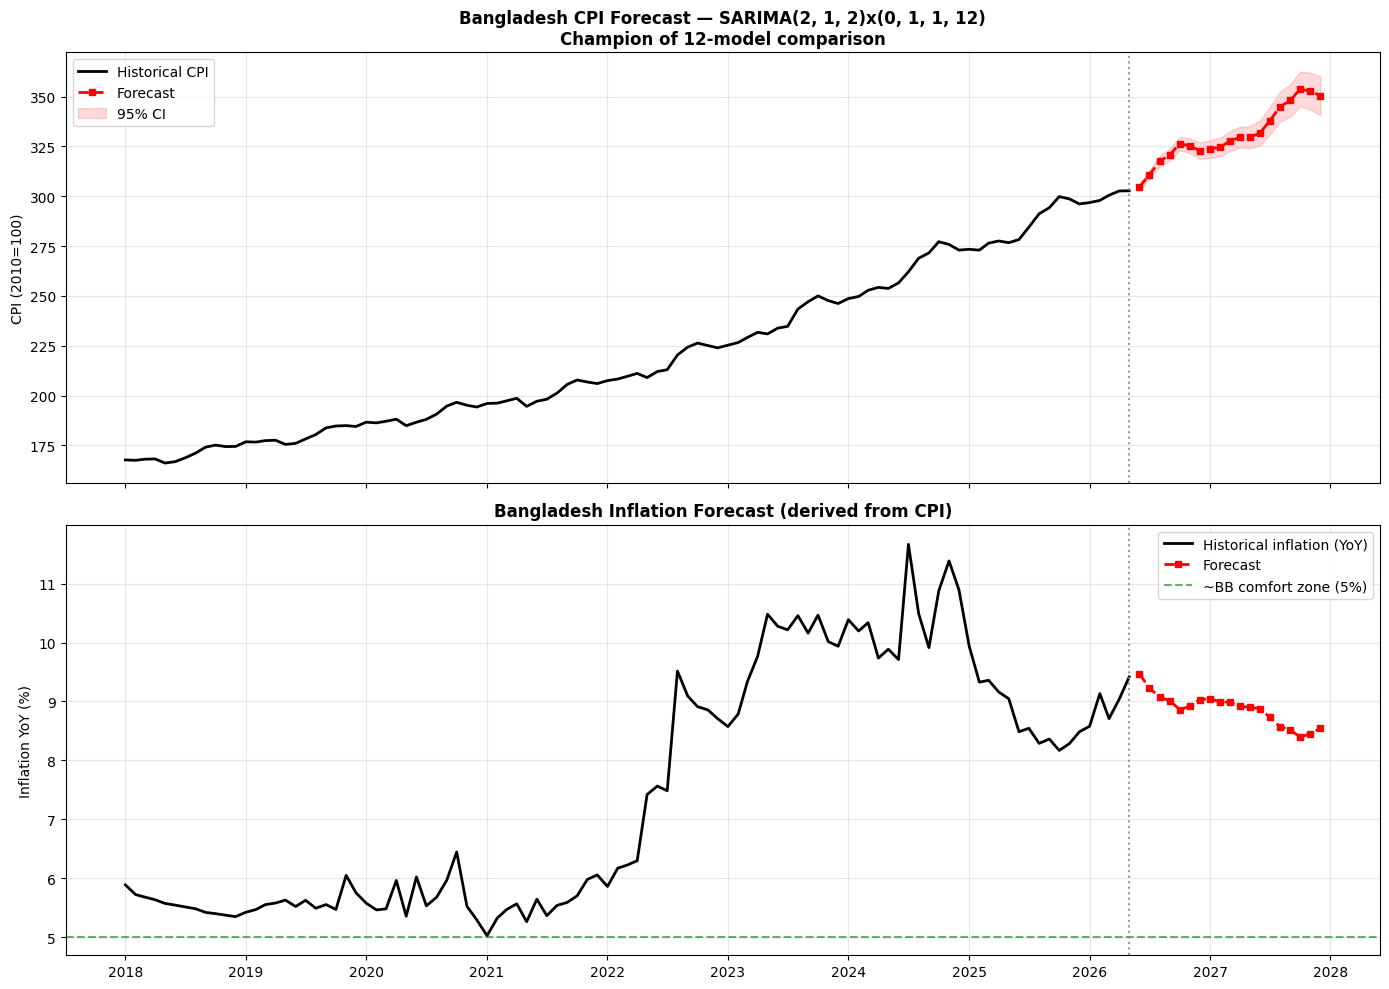

✅ Final chart saved — this is your paper's centerpiece figure


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Panel 1: CPI ──
hist = y_all.loc['2018-01-01':]
axes[0].plot(hist.index, hist, 'k-', lw=2, label='Historical CPI')
axes[0].plot(cpi_fc.index, cpi_fc, 'r--s', ms=4, lw=2, label='Forecast')
axes[0].fill_between(cpi_fc.index, ci.iloc[:,0], ci.iloc[:,1],
                     color='red', alpha=0.15, label='95% CI')
axes[0].axvline(pd.Timestamp('2026-05-01'), color='gray', ls=':', alpha=0.8)
axes[0].set_title(f'Bangladesh CPI Forecast — SARIMA{SARIMA_ORDER}x{SARIMA_SORDER}\n'
                  'Champion of 12-model comparison', fontweight='bold')
axes[0].set_ylabel('CPI (2010=100)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Panel 2: Inflation ──
infl_hist = (y_all.pct_change(12)*100).loc['2018-01-01':]
axes[1].plot(infl_hist.index, infl_hist, 'k-', lw=2, label='Historical inflation (YoY)')
axes[1].plot(infl_fc.index, infl_fc, 'r--s', ms=4, lw=2, label='Forecast')
axes[1].axhline(y=5, color='green', ls='--', alpha=0.6, label='~BB comfort zone (5%)')
axes[1].axvline(pd.Timestamp('2026-05-01'), color='gray', ls=':', alpha=0.8)
axes[1].set_title('Bangladesh Inflation Forecast (derived from CPI)', fontweight='bold')
axes[1].set_ylabel('Inflation YoY (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FOLDER}/FINAL_forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final chart saved — this is your paper's centerpiece figure")